#**Predictive Analytics for Smart Electric Vehicle Charging Station Recommendation**

###**Objective**
**Analyze EV Charging Patterns**

* To explore and understand electric vehicle charging behavior using exploratory data analysis (EDA).

* To identify trends in charging duration, charging cost, energy consumption, and charging rate.

**Study Energy Consumption and Charging Performance**

* To examine the relationship between battery capacity, energy consumed, charging duration, and charging rate.

* To identify the factors that influence charging efficiency.

**Evaluate Charging Cost Patterns**

* To analyze charging costs across different charging stations, charger types, and time periods.

* To identify cost-efficient charging options for EV users.

**Compare Charging Station Performance**

* To compare charging stations based on charging duration, charging cost, charging rate, and energy delivered.

* To identify high-performing charging stations

**Identify Factors Affecting Charging Duration**

* To investigate how charging duration is influenced by battery gain, charging rate, battery capacity, and environmental temperature.

**Predict Charging Duration Using Machine Learning**

* To build and evaluate a Random Forest Regression model that predicts charging duration based on charging session characteristics.



#**DATASET INFORMATION**


Dataset Source

Source: Gigasheet Dataset – EV Charging Patterns

Dataset Size
Approximately 1,320 charging session records
More than 20 features

Location: United States

Timeline: 2024


Domain

Electric Vehicles (EV), Energy Management, and Transportation Analytics

#**DATASET FEATURE**
User ID – A unique identifier assigned to each EV user.

Vehicle Model – The model of the electric vehicle used.

Battery Capacity – The total battery capacity of the vehicle, measured in kilowatt-hours (kWh).

Charging Station – The location or name of the charging station where the vehicle was charged.

Charging Start Time – The date and time when the charging session began.

Charging End Time – The date and time when the charging session ended.

Charging Duration – The total time taken to complete the charging session.

Energy Consumed – The amount of electrical energy consumed during charging, measured in kWh.

Charging Cost – The total cost incurred for the charging session.

Charging Rate – The speed at which the vehicle was charged.

State of Charge (Start) – The battery percentage before charging started.

State of Charge (End) – The battery percentage after charging was completed.

Distance Driven – The distance traveled by the vehicle before charging.

Temperature – The ambient temperature during the charging session.

Vehicle Age – The age of the electric vehicle.

Charger Type – The type of charger used, such as Fast Charger or Slow Charger.

User Type – The category of the EV user (for example, private or commercial user).

Time of Day – The period during which charging occurred, such as Morning, Afternoon, Evening, or Night.

Day of Week – The day on which the charging session took place.

In [2]:
# IMPORT LIBRARIES


import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.style.use('ggplot')

pd.set_option('display.max_columns', None)

url="https://raw.githubusercontent.com/ayshamohamedismail-alt/Electric-Vehicle-Charging-Pattern-Analysis/refs/heads/main/EV_Charging_Patterns.csv"
ev=pd.read_csv(url)

#**Intial EDA**

In [86]:
# DATASET OVERVIEW

print("Rows and Columns :", ev.shape)
print("\nColumn Names:\n")
print(ev.columns.tolist())

print("\nData Types:\n")
print(ev.dtypes)
print("\nSummary Statistics:\n")
ev.describe()

Rows and Columns : (1320, 22)

Column Names:

['user_id', 'vehicle_model', 'battery_capacity_(kwh)', 'charging_station_id', 'charging_station_location', 'charging_start_time', 'charging_end_time', 'energy_consumed_(kwh)', 'charging_duration_(hours)', 'charging_rate_(kw)', 'charging_cost_(usd)', 'time_of_day', 'day_of_week', 'state_of_charge_(start_%)', 'state_of_charge_(end_%)', 'distance_driven_(since_last_charge)_(km)', 'temperature_(°c)', 'vehicle_age_(years)', 'charger_type', 'user_type', 'battery_gain', 'cost_per_kwh']

Data Types:

user_id                                             object
vehicle_model                                       object
battery_capacity_(kwh)                             float64
charging_station_id                                 object
charging_station_location                           object
charging_start_time                         datetime64[ns]
charging_end_time                           datetime64[ns]
energy_consumed_(kwh)                      

,battery_capacity_(kwh),charging_start_time,charging_end_time,energy_consumed_(kwh),charging_duration_(hours),charging_rate_(kw),charging_cost_(usd),state_of_charge_(start_%),state_of_charge_(end_%),distance_driven_(since_last_charge)_(km),temperature_(°c),vehicle_age_(years),battery_gain,cost_per_kwh
count,1320.000000,1320,1320,1254.000000,1320.000000,1254.000000,1320.000000,1320.000000,1320.000000,1254.000000,1320.000000,1320.000000,1320.000000,1254.000000
mean,74.534692,2024-01-28 11:30:00,2024-01-28 13:43:30.863636480,42.642894,2.269377,25.963003,22.551352,49.130012,75.141590,153.596788,15.263591,3.612843,2.225240,1.660717
min,1.532807,2024-01-01 00:00:00,2024-01-01 00:39:00,0.045772,0.095314,1.472549,0.234317,2.325959,7.604224,0.862361,-10.724770,0.000000,0.500000,0.004520
25%,62.000000,2024-01-14 17:45:00,2024-01-14 19:34:30,23.881193,1.397623,13.856583,13.368141,27.786903,62.053266,79.445335,2.800664,2.000000,1.379167,0.297563
50%,75.000000,2024-01-28 11:30:00,2024-01-28 14:07:00,42.691405,2.258136,25.603799,22.076360,48.241771,75.682496,152.259867,14.630846,4.000000,2.183333,0.541345
75%,85.000000,2024-02-11 05:15:00,2024-02-11 07:39:00,61.206218,3.112806,37.502998,31.646044,69.277921,88.201370,226.073284,27.981810,6.000000,3.083333,0.960437
max,193.003074,2024-02-24 23:00:00,2024-02-24 23:56:00,152.238758,7.635145,97.342255,69.407743,152.489761,177.708666,398.364775,73.169588,11.688592,3.983333,654.762090
std,20.626914,NaN,NaN,22.411705,1.061037,14.011326,10.751494,24.074134,17.080580,86.004987,14.831216,2.309824,1.008414,20.468415


In [87]:
ev.head()

,user_id,vehicle_model,battery_capacity_(kwh),charging_station_id,charging_station_location,charging_start_time,charging_end_time,energy_consumed_(kwh),charging_duration_(hours),charging_rate_(kw),charging_cost_(usd),time_of_day,day_of_week,state_of_charge_(start_%),state_of_charge_(end_%),distance_driven_(since_last_charge)_(km),temperature_(°c),vehicle_age_(years),charger_type,user_type,battery_gain,cost_per_kwh
0,User_1,BMW i3,108.463007,Station_391,Houston,2024-01-01 00:00:00,2024-01-01 00:39:00,60.712346,0.591363,36.389181,13.087717,Evening,Tuesday,29.371576,86.119962,293.602111,27.947953,2.0,DC Fast Charger,Commuter,0.650000,0.215569
1,User_2,Hyundai Kona,100.000000,Station_428,San Francisco,2024-01-01 01:00:00,2024-01-01 03:01:00,12.339275,3.133652,30.677735,21.128448,Morning,Monday,10.115778,84.664344,112.112804,14.311026,3.0,Level 1,Casual Driver,2.016667,1.712292
2,User_3,Chevy Bolt,75.000000,Station_181,San Francisco,2024-01-01 02:00:00,2024-01-01 04:48:00,19.128876,2.452653,27.513593,35.667270,Morning,Thursday,6.854604,69.917615,71.799253,21.002002,2.0,Level 2,Commuter,2.800000,1.864577
3,User_4,Hyundai Kona,50.000000,Station_327,Houston,2024-01-01 03:00:00,2024-01-01 06:42:00,79.457824,1.266431,32.882870,13.036239,Evening,Saturday,83.120003,99.624328,199.577785,38.316313,1.0,Level 1,Long-Distance Traveler,3.700000,0.164065
4,User_5,Hyundai Kona,50.000000,Station_108,Los Angeles,2024-01-01 04:00:00,2024-01-01 05:46:00,19.629104,2.019765,10.215712,10.161471,Morning,Saturday,54.258950,63.743786,203.661847,-7.834199,1.0,Level 1,Long-Distance Traveler,1.766667,0.517674


#**Data Cleaning**

In [84]:
print("\nMissing Values:\n")
print(ev.isnull().sum())

print("\nDuplicate Rows :", ev.duplicated().sum())


Missing Values:

user_id                                      0
vehicle_model                                0
battery_capacity_(kwh)                       0
charging_station_id                          0
charging_station_location                    0
charging_start_time                          0
charging_end_time                            0
energy_consumed_(kwh)                       66
charging_duration_(hours)                    0
charging_rate_(kw)                          66
charging_cost_(usd)                          0
time_of_day                                  0
day_of_week                                  0
state_of_charge_(start_%)                    0
state_of_charge_(end_%)                      0
distance_driven_(since_last_charge)_(km)    66
temperature_(°c)                             0
vehicle_age_(years)                          0
charger_type                                 0
user_type                                    0
battery_gain                              

In [9]:
# HANDLE MISSING VALUES

num_cols = ev.select_dtypes(include=['float64','int64']).columns

for col in num_cols:
    ev[col].fillna(ev[col].median(), inplace=True)

ev.isnull().sum()

,0
User ID,0
Vehicle Model,0
Battery Capacity (kWh),0
Charging Station ID,0
Charging Station Location,0
Charging Start Time,0
Charging End Time,0
Energy Consumed (kWh),0
Charging Duration (hours),0
Charging Rate (kW),0


In [11]:
#renaming the columns

ev.columns=ev.columns.str.lower().str.replace(" ","_")

In [12]:
# DATE CONVERSION

ev['charging_start_time'] = pd.to_datetime(ev['charging_start_time'])

ev['charging_end_time'] = pd.to_datetime(ev['charging_end_time'])

#**Data Transformation and Feature Engineering**

In [88]:
#Feature Engineering

ev['charging_hour'] = ev['charging_start_time'].dt.hour
ev['charging_month'] = ev['charging_start_time'].dt.month_name()
ev['charging_date'] = ev['charging_start_time'].dt.date
ev['is_weekend'] = ev['day_of_week'].isin(
    ['Saturday','Sunday']
)
ev['peak_hour'] = ev['charging_hour'].apply(
    lambda x: 'Peak' if 18 <= x <= 21 else 'Non Peak'
)
ev['battery_gain']=ev['charging_end_time']-ev['charging_start_time']

# Convert 'battery_gain' from Timedelta to total hours immediately after creation
ev['battery_gain'] = ev['battery_gain'].dt.total_seconds() / 3600

ev['vehicle_age_category']=pd.cut(
    ev['vehicle_age_(years)'],
    bins=[0,3,7,15],
    labels=['New','Medium','Old']
)
ev['cost_per_kwh']=ev['charging_cost_(usd)']/ev['energy_consumed_(kwh)']

ev['charging_speed'] = pd.cut(
    ev['charging_rate_(kw)'],
    bins=[0,22,50,150,1000],
    labels=[
        'Slow',
        'Fast',
        'Rapid',
        'Ultra Fast'
    ]
)

#**Final EDA**


In [91]:
ev.head()

,user_id,vehicle_model,battery_capacity_(kwh),charging_station_id,charging_station_location,charging_start_time,charging_end_time,energy_consumed_(kwh),charging_duration_(hours),charging_rate_(kw),charging_cost_(usd),time_of_day,day_of_week,state_of_charge_(start_%),state_of_charge_(end_%),distance_driven_(since_last_charge)_(km),temperature_(°c),vehicle_age_(years),charger_type,user_type,battery_gain,cost_per_kwh,charging_hour,charging_month,charging_date,is_weekend,peak_hour,vehicle_age_category,charging_speed
0,User_1,BMW i3,108.463007,Station_391,Houston,2024-01-01 00:00:00,2024-01-01 00:39:00,60.712346,0.591363,36.389181,13.087717,Evening,Tuesday,29.371576,86.119962,293.602111,27.947953,2.0,DC Fast Charger,Commuter,0.650000,0.215569,0,January,2024-01-01,False,Non Peak,New,Fast
1,User_2,Hyundai Kona,100.000000,Station_428,San Francisco,2024-01-01 01:00:00,2024-01-01 03:01:00,12.339275,3.133652,30.677735,21.128448,Morning,Monday,10.115778,84.664344,112.112804,14.311026,3.0,Level 1,Casual Driver,2.016667,1.712292,1,January,2024-01-01,False,Non Peak,New,Fast
2,User_3,Chevy Bolt,75.000000,Station_181,San Francisco,2024-01-01 02:00:00,2024-01-01 04:48:00,19.128876,2.452653,27.513593,35.667270,Morning,Thursday,6.854604,69.917615,71.799253,21.002002,2.0,Level 2,Commuter,2.800000,1.864577,2,January,2024-01-01,False,Non Peak,New,Fast
3,User_4,Hyundai Kona,50.000000,Station_327,Houston,2024-01-01 03:00:00,2024-01-01 06:42:00,79.457824,1.266431,32.882870,13.036239,Evening,Saturday,83.120003,99.624328,199.577785,38.316313,1.0,Level 1,Long-Distance Traveler,3.700000,0.164065,3,January,2024-01-01,True,Non Peak,New,Fast
4,User_5,Hyundai Kona,50.000000,Station_108,Los Angeles,2024-01-01 04:00:00,2024-01-01 05:46:00,19.629104,2.019765,10.215712,10.161471,Morning,Saturday,54.258950,63.743786,203.661847,-7.834199,1.0,Level 1,Long-Distance Traveler,1.766667,0.517674,4,January,2024-01-01,True,Non Peak,New,Slow


In [90]:
print("Rows and Columns :", ev.shape)
print("\nColumn Names:\n")
print(ev.columns.tolist())

print("\nData Types:\n")
print(ev.dtypes)
print("\nSummary Statistics:\n")
ev.describe()

Rows and Columns : (1320, 29)

Column Names:

['user_id', 'vehicle_model', 'battery_capacity_(kwh)', 'charging_station_id', 'charging_station_location', 'charging_start_time', 'charging_end_time', 'energy_consumed_(kwh)', 'charging_duration_(hours)', 'charging_rate_(kw)', 'charging_cost_(usd)', 'time_of_day', 'day_of_week', 'state_of_charge_(start_%)', 'state_of_charge_(end_%)', 'distance_driven_(since_last_charge)_(km)', 'temperature_(°c)', 'vehicle_age_(years)', 'charger_type', 'user_type', 'battery_gain', 'cost_per_kwh', 'charging_hour', 'charging_month', 'charging_date', 'is_weekend', 'peak_hour', 'vehicle_age_category', 'charging_speed']

Data Types:

user_id                                             object
vehicle_model                                       object
battery_capacity_(kwh)                             float64
charging_station_id                                 object
charging_station_location                           object
charging_start_time                     

,battery_capacity_(kwh),charging_start_time,charging_end_time,energy_consumed_(kwh),charging_duration_(hours),charging_rate_(kw),charging_cost_(usd),state_of_charge_(start_%),state_of_charge_(end_%),distance_driven_(since_last_charge)_(km),temperature_(°c),vehicle_age_(years),battery_gain,cost_per_kwh,charging_hour
count,1320.000000,1320,1320,1254.000000,1320.000000,1254.000000,1320.000000,1320.000000,1320.000000,1254.000000,1320.000000,1320.000000,1320.000000,1254.000000,1320.00000
mean,74.534692,2024-01-28 11:30:00,2024-01-28 13:43:30.863636480,42.642894,2.269377,25.963003,22.551352,49.130012,75.141590,153.596788,15.263591,3.612843,2.225240,1.660717,11.50000
min,1.532807,2024-01-01 00:00:00,2024-01-01 00:39:00,0.045772,0.095314,1.472549,0.234317,2.325959,7.604224,0.862361,-10.724770,0.000000,0.500000,0.004520,0.00000
25%,62.000000,2024-01-14 17:45:00,2024-01-14 19:34:30,23.881193,1.397623,13.856583,13.368141,27.786903,62.053266,79.445335,2.800664,2.000000,1.379167,0.297563,5.75000
50%,75.000000,2024-01-28 11:30:00,2024-01-28 14:07:00,42.691405,2.258136,25.603799,22.076360,48.241771,75.682496,152.259867,14.630846,4.000000,2.183333,0.541345,11.50000
75%,85.000000,2024-02-11 05:15:00,2024-02-11 07:39:00,61.206218,3.112806,37.502998,31.646044,69.277921,88.201370,226.073284,27.981810,6.000000,3.083333,0.960437,17.25000
max,193.003074,2024-02-24 23:00:00,2024-02-24 23:56:00,152.238758,7.635145,97.342255,69.407743,152.489761,177.708666,398.364775,73.169588,11.688592,3.983333,654.762090,23.00000
std,20.626914,NaN,NaN,22.411705,1.061037,14.011326,10.751494,24.074134,17.080580,86.004987,14.831216,2.309824,1.008414,20.468415,6.92481


#**Statistical Analysis And Visualizations**

In [82]:
#Charging Cost Analysis
cost = ev['charging_cost_(usd)']

print("Summary Statistics:")
print("Mean :", cost.mean())
print("Median :", cost.median())
print("Mode :", cost.mode()[0])
print("Standard Deviation :", cost.std())
print("Variance :", cost.var())
print("Minimum :", cost.min())
print("Maximum :", cost.max())
print("Skewness :", cost.skew())
print("Kurtosis :", cost.kurt())



Summary Statistics:
Mean : 22.551351747804052
Median : 22.076360159476437
Mode : 0.2343169936142865
Standard Deviation : 10.751493625497588
Variance : 115.59461517911525
Minimum : 0.2343169936142865
Maximum : 69.40774319393012
Skewness : 0.2509190452665847
Kurtosis : -0.48734652719632754


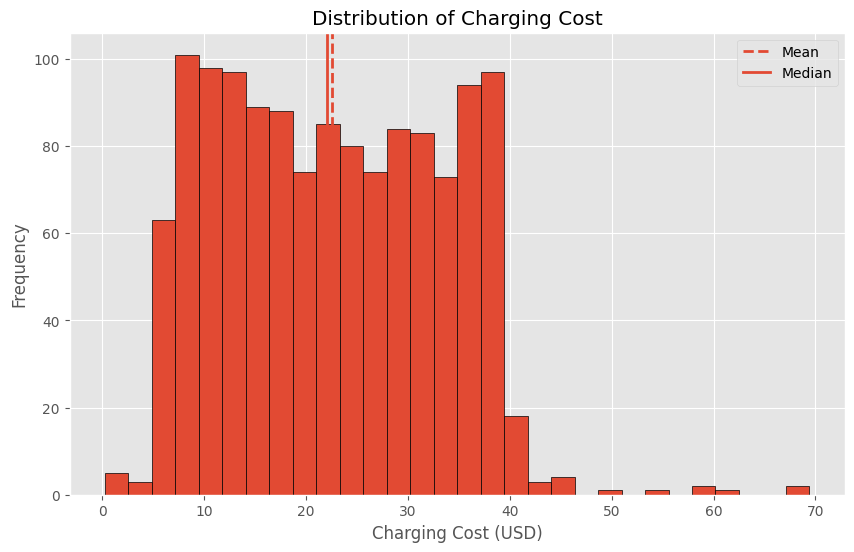

In [81]:
plt.figure(figsize=(10,6))

plt.hist(cost, bins=30, edgecolor='black')

plt.axvline(cost.mean(), linestyle='--', linewidth=2, label='Mean')

plt.axvline(cost.median(), linestyle='-', linewidth=2, label='Median')

plt.title("Distribution of Charging Cost")

plt.xlabel("Charging Cost (USD)")

plt.ylabel("Frequency")

plt.legend()

plt.show()

###**Interpretation**

* The majority of charging sessions cost between $8 and $40, with the highest frequency around $10–$20 and $30–$40.

* The mean and median are both around $22, indicating the average charging cost is close to the middle value and the distribution is fairly balanced.

* A few charging sessions have costs above $45, with the maximum reaching approximately $70, representing outliers.

* Most users incur moderate charging costs, while only a small percentage experience unusually high charging expenses.

#**Univariate Analysis**

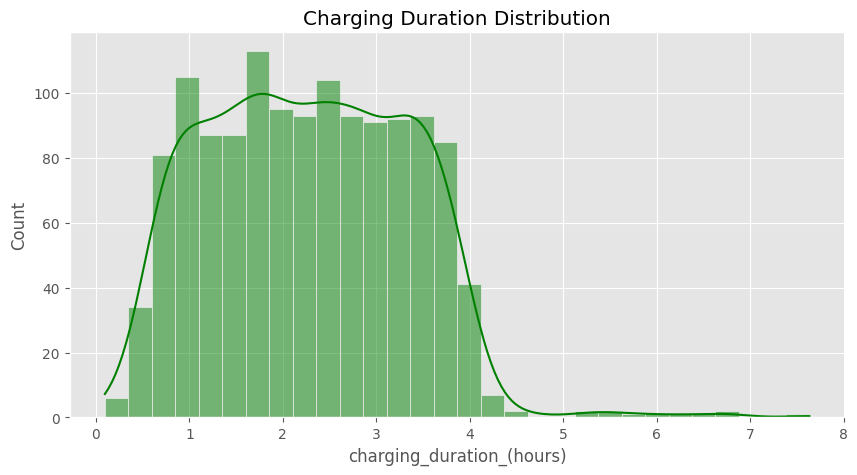

In [17]:
#Charging Duration
plt.figure(figsize=(10,5))

sns.histplot(
    ev['charging_duration_(hours)'],
    bins=30,
    kde=True,
    color='green'
)

plt.title("Charging Duration Distribution")

plt.show()

###**Interpretation**

* Most charging sessions last between 1 and 4 hours, with the highest frequency around 1.5–3.5 hours.

* Very short charging sessions (less than 0.5 hours) are uncommon.

* Charging sessions longer than 5 hours are rare and represent only a small number of observations.

* The distribution is slightly right-skewed, indicating that while most charging sessions finish within a few hours, a few sessions take significantly longer.

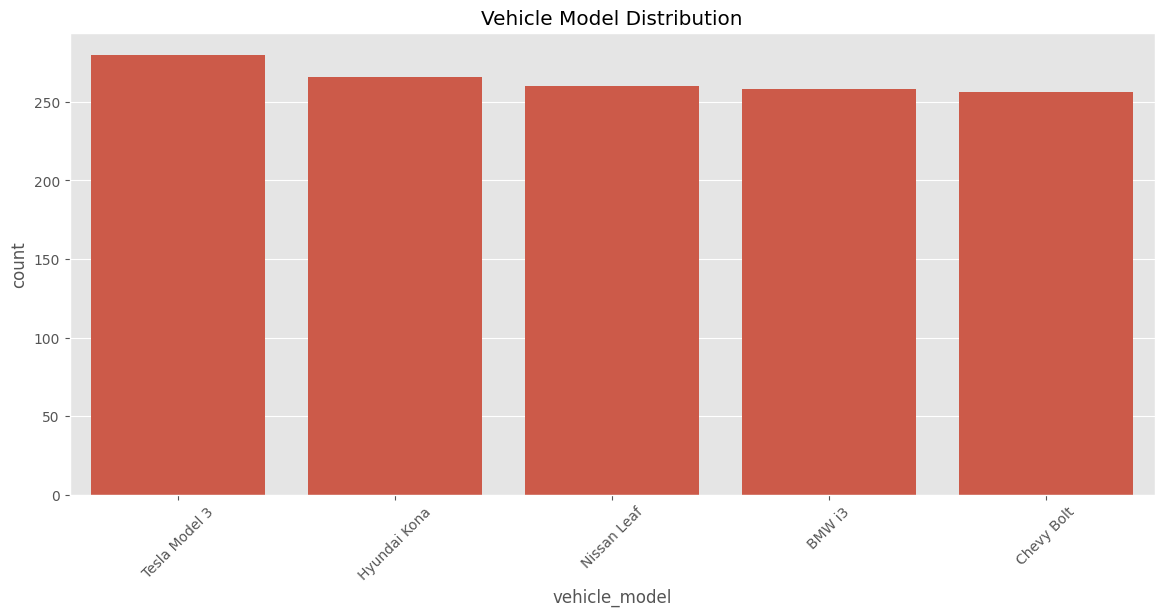

In [18]:
#Vehicle Model Analysis
plt.figure(figsize=(14,6))

sns.countplot(
    data=ev,
    x='vehicle_model',
    order=ev['vehicle_model'].value_counts().index
)

plt.xticks(rotation=45)

plt.title("Vehicle Model Distribution")

plt.show()

###**Interpretation**

* Tesla Model 3 has the highest number of charging sessions with approximately 280 records.

* Hyundai Kona follows with around 266 records.

* Nissan Leaf, BMW i3, and Chevy Bolt each have approximately 258–260 records.

* The dataset is well balanced across all five vehicle models, ensuring fair comparisons during analysis and machine learning.

###

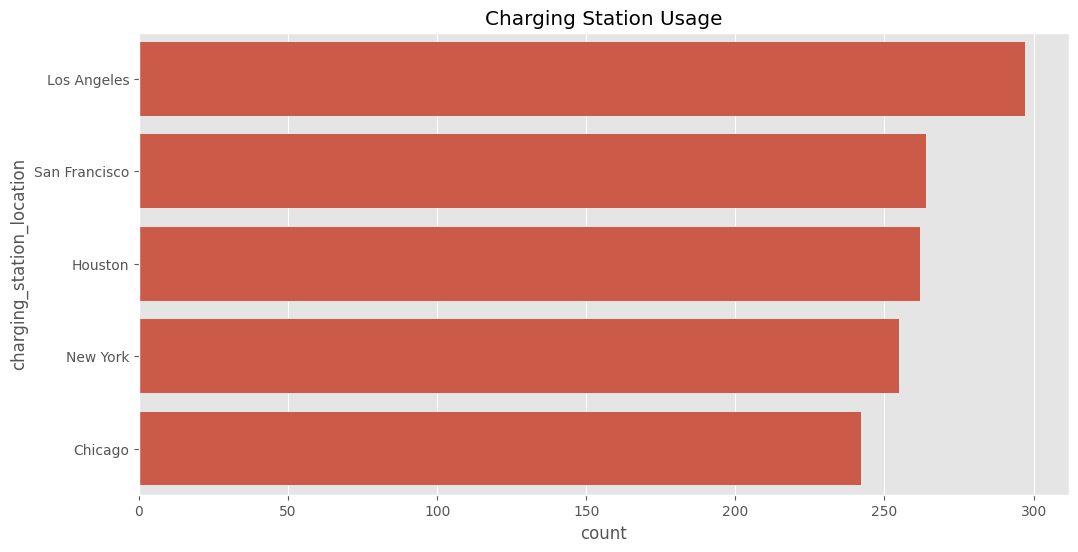

In [19]:
#Top Charging Stations
plt.figure(figsize=(12,6))

sns.countplot(
    data=ev,
    y='charging_station_location',
    order=ev['charging_station_location'].value_counts().index
)

plt.title("Charging Station Usage")

plt.show()

###**Interpretation**


* Los Angeles has the highest charging station usage with approximately 298 charging sessions.

* San Francisco and Houston each record around 262–265 sessions, indicating similarly high utilization.

* New York has approximately 255 charging sessions.

* Chicago has the lowest usage with about 243 charging sessions, but the differences among cities are relatively small, suggesting balanced station utilization across locations.

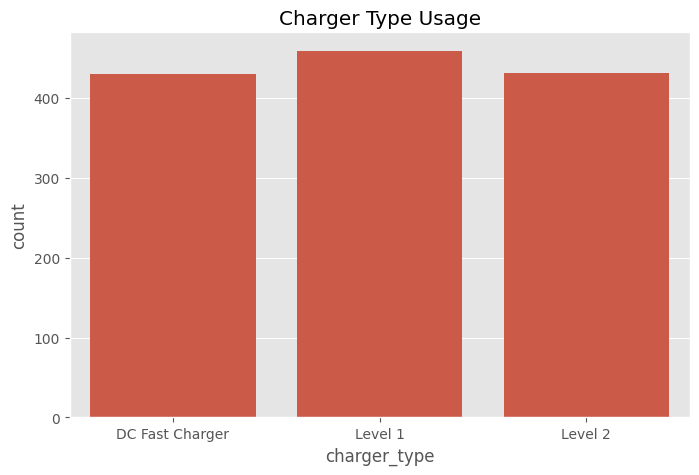

In [20]:
#Charger Type
plt.figure(figsize=(8,5))

sns.countplot(
    data=ev,
    x='charger_type'
)

plt.title("Charger Type Usage")

plt.show()

###**Interpretation**

* Level 1 chargers are the most frequently used, with approximately 460 charging sessions.

* DC Fast Chargers and Level 2 chargers each have approximately 430 charging sessions.

* The difference between charger types is relatively small, indicating that users utilize all charger types regularly.

* The balanced distribution makes it suitable for comparing charging performance across different charger types.

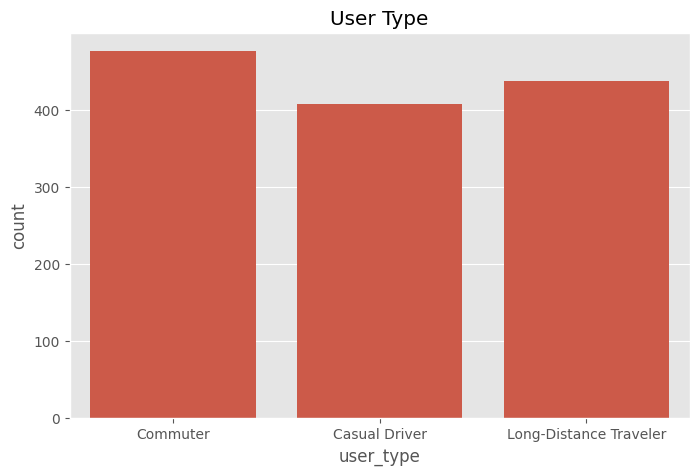

In [21]:
#User Type
plt.figure(figsize=(8,5))

sns.countplot(
    data=ev,
    x='user_type'
)

plt.title("User Type")

plt.show()

###**Interpretation**

* Commuters represent the largest user group with approximately 475 charging sessions.

* Long-Distance Travelers account for around 438 charging sessions.

* Casual Drivers have the lowest count with approximately 408 charging sessions.

* The dataset includes a balanced representation of all user types, making it useful for understanding charging behavior across different driving patterns.

#**Bivariate Analysis**

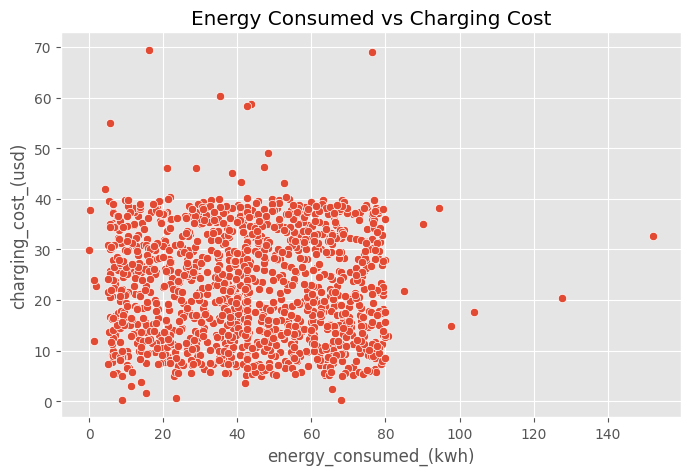

In [22]:
#Charging Cost vs Energy Consumed
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=ev,
    x='energy_consumed_(kwh)',
    y='charging_cost_(usd)'
)

plt.title("Energy Consumed vs Charging Cost")

plt.show()

###**Interpretation**

* Most charging sessions consume between 5 and 80 kWh, while charging costs generally range from $5 to $40.

* As energy consumption increases, charging cost generally increases, indicating a positive relationship between the two variables.

* A few sessions consume more than 100 kWh, but these are rare compared to the majority of observations.

* Some charging sessions have high energy consumption but relatively moderate costs, suggesting that factors such as charging rates or pricing differences also affect the total charging cost.

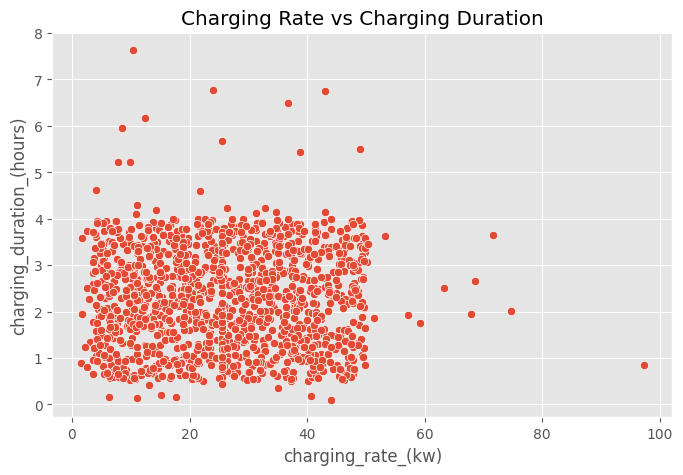

In [23]:
#Charging Rate vs Charging Duration
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=ev,
    x='charging_rate_(kw)',
    y='charging_duration_(hours)'
)

plt.title("Charging Rate vs Charging Duration")

plt.show()

###**Interpretation**

* Most charging rates lie between 5 and 50 kW, while charging durations are typically between 1 and 4 hours.

* Higher charging rates are generally associated with shorter charging durations, showing an inverse relationship.

* A small number of charging sessions last more than 6 hours, representing unusual or slow charging events.

* Charging rates above 60 kW are less common and usually result in charging durations below 3 hours.

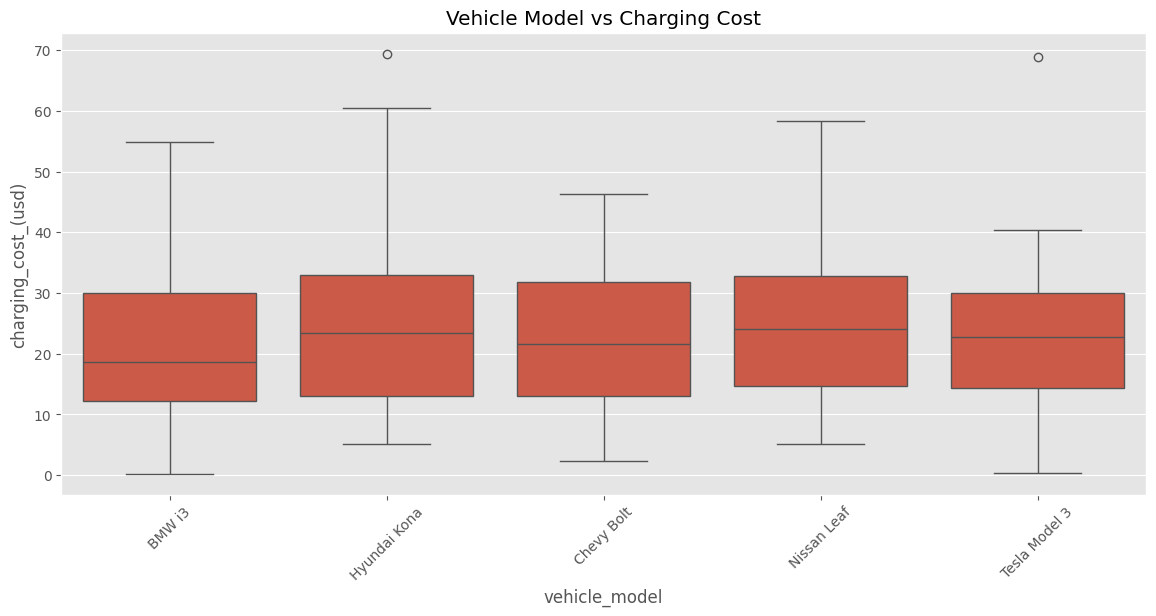

In [24]:
#Vehicle Model vs Charging Cost
plt.figure(figsize=(14,6))

sns.boxplot(
    data=ev,
    x='vehicle_model',
    y='charging_cost_(usd)'
)

plt.xticks(rotation=45)

plt.title("Vehicle Model vs Charging Cost")

plt.show()

###**Interpretation**

* The median charging cost for all vehicle models is relatively similar, ranging between $19 and $24.

* Nissan Leaf and Hyundai Kona show slightly higher median charging costs compared to the other models.

* All vehicle models contain a few high-cost outliers, with maximum charging costs reaching approximately $55–$70.

* Overall, charging costs are fairly consistent across different vehicle models, indicating that vehicle type has only a limited impact on charging cost.

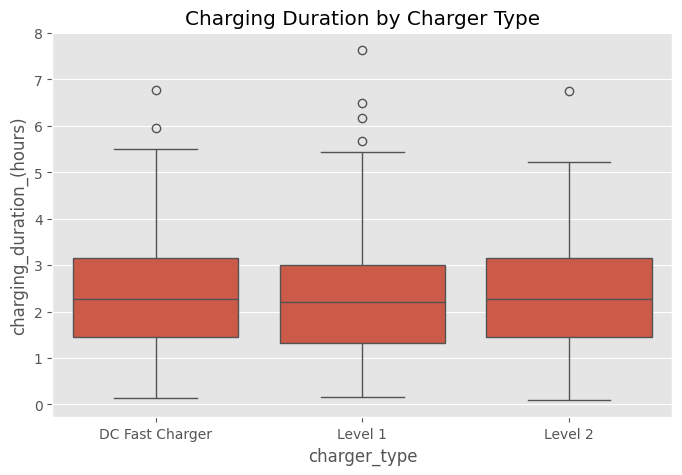

In [25]:
#Charger Type vs Charging Duration
plt.figure(figsize=(8,5))

sns.boxplot(
    data=ev,
    x='charger_type',
    y='charging_duration_(hours)'
)

plt.title("Charging Duration by Charger Type")

plt.show()

###**Interpretation**

* The median charging duration for DC Fast Charger, Level 1, and Level 2 chargers is approximately 2.2–2.3 hours.

* The spread of charging duration is similar across all charger types, with most sessions lasting between 1.5 and 3 hours.

* A few charging sessions exceed 5.5 hours, appearing as outliers for each charger type.
4
* Overall, charging duration does not differ substantially among the three charger types in this dataset.

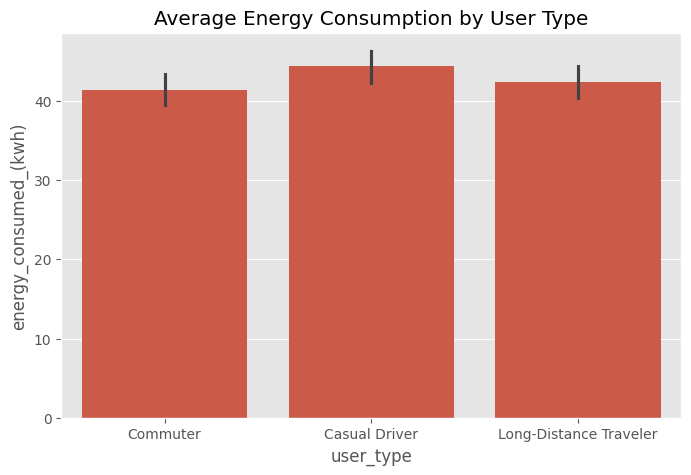

In [26]:
#User Type vs Energy Consumed
plt.figure(figsize=(8,5))

sns.barplot(
    data=ev,
    x='user_type',
    y='energy_consumed_(kwh)'
)

plt.title("Average Energy Consumption by User Type")

plt.show()

###**Interpretation**

* Casual Drivers have the highest average energy consumption at approximately 44–45 kWh.

* Long-Distance Travelers consume around 42–43 kWh on average.

* Commuters have the lowest average energy consumption at approximately 41–42 kWh.

* The difference between user groups is relatively small (around 3–4 kWh), indicating that energy consumption is fairly consistent across user types.

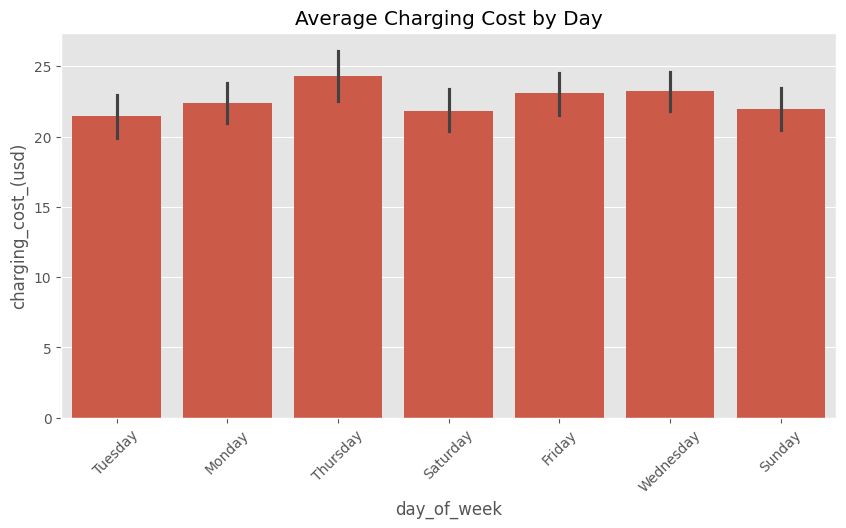

In [27]:
#Day of Week vs Charging Cost
plt.figure(figsize=(10,5))

sns.barplot(
    data=ev,
    x='day_of_week',
    y='charging_cost_(usd)'
)

plt.xticks(rotation=45)

plt.title("Average Charging Cost by Day")

plt.show()

###**Interpretation**

* Thursday has the highest average charging cost at approximately $24–$25.

* Tuesday has the lowest average charging cost at around $21–$22.

* The remaining days (Monday, Wednesday, Friday, Saturday, and Sunday) have average charging costs between $22 and $23.5.

* The variation in charging cost across the week is relatively small (about $3), suggesting that charging costs remain fairly stable regardless of the day.

###**Multivariate Analysis**

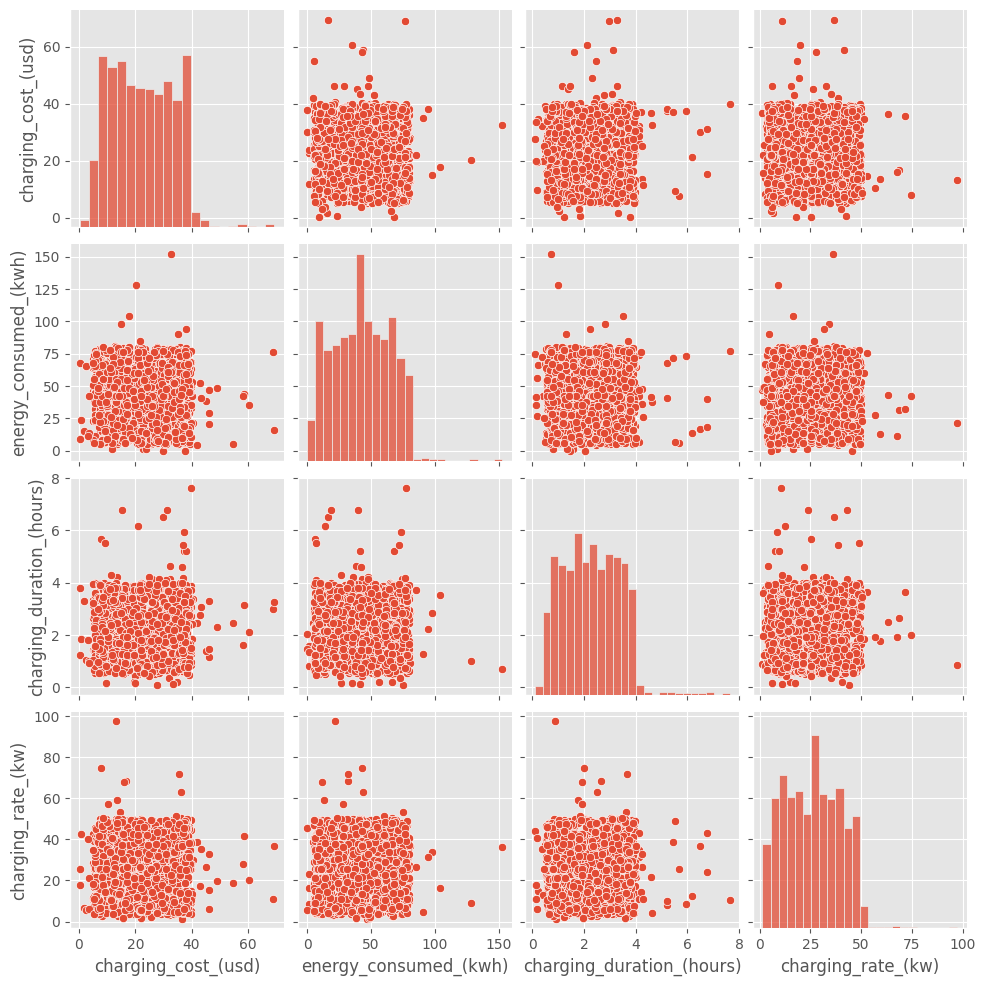

In [30]:
#Pair Plot
sns.pairplot(
    ev[
        [
            'charging_cost_(usd)',
            'energy_consumed_(kwh)',
            'charging_duration_(hours)',
            'charging_rate_(kw)',
            'battery_gain'
        ]
    ]
)

plt.show()

###**Interpretation**

* Most charging sessions have a charging cost between $5 and $40, energy consumption between 10 and 80 kWh, charging duration between 1 and 4 hours, and charging rates between 5 and 50 kW.

* The scatter plots show no strong linear relationship between most variable pairs, indicating that charging behavior is influenced by multiple factors rather than a single variable.

* A few outliers are present, such as energy consumption above 100 kWh, charging costs around $70, charging rates close to 100 kW, and charging durations above 7 hours. These represent rare charging sessions.

* The histograms on the diagonal show that most variables are concentrated within common operating ranges, with only a few extreme values.

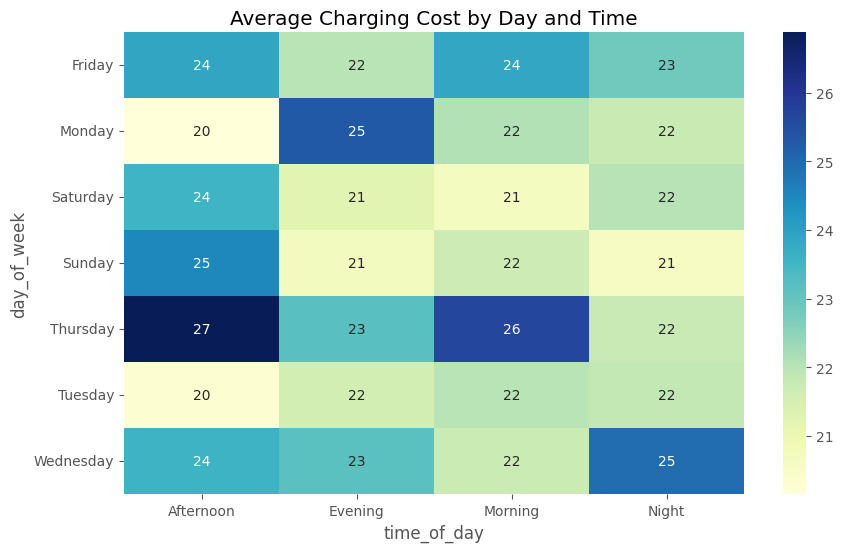

In [33]:
#Heat Map
pivot = ev.pivot_table(
    values='charging_cost_(usd)',
    index='day_of_week',
    columns='time_of_day',
    aggfunc='mean'
)

plt.figure(figsize=(10,6))

sns.heatmap(
    pivot,
    annot=True,
    cmap='YlGnBu'
)

plt.title("Average Charging Cost by Day and Time")

plt.show()

###**Interpretation**

* Thursday Afternoon records the highest average charging cost at approximately 27usd, followed by Thursday Morning at around $26.

* Monday Evening and Wednesday Night also show relatively high average charging costs of approximately $25.

* The lowest average charging costs (around $20) occur on Monday Afternoon and Tuesday Afternoon.

* Most other day-and-time combinations have average charging costs between $21 and $24, indicating that charging costs remain fairly stable throughout the week.

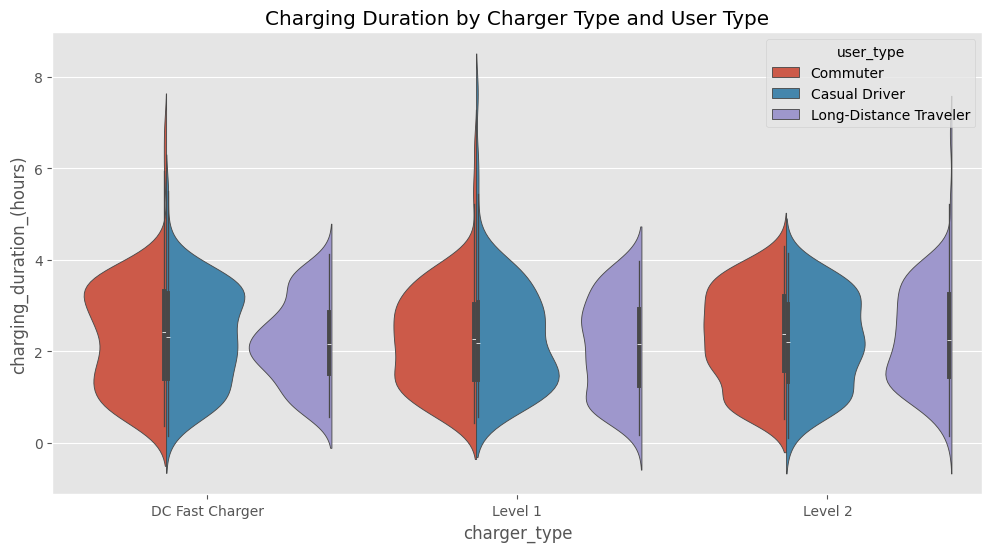

In [34]:
#Violin Plot
plt.figure(figsize=(12,6))

sns.violinplot(
    data=ev,
    x='charger_type',
    y='charging_duration_(hours)',
    hue='user_type',
    split=True
)

plt.title("Charging Duration by Charger Type and User Type")

plt.show()

###**Interpretation**

* Typical Charging Time (2 to 3 Hours): Across all charger types and user categories, the main body (widest part) of the distributions is concentrated between 2 and 3 hours, indicating that most users complete their charging session within this timeframe.

* Maximum Duration Peaks (Up to 8.5 Hours): Some sessions take significantly longer, reaching maximum peaks of around 7.5 to 8.5 hours (visible in the long upper tails), representing extended or overnight charging sessions.

* Similar Patterns for Commuters & Casual Drivers: Both Commuters (red) and Casual Drivers (blue) show almost identical wide distributions, with median charging durations around 2.2 to 2.5 hours.

* Shorter Sessions for Long-Distance Travelers: Long-Distance Travelers (purple) generally spend less time plugged in, with their sessions topping out at around 4.5 to 5 hours and a median duration closer to 2 hours.

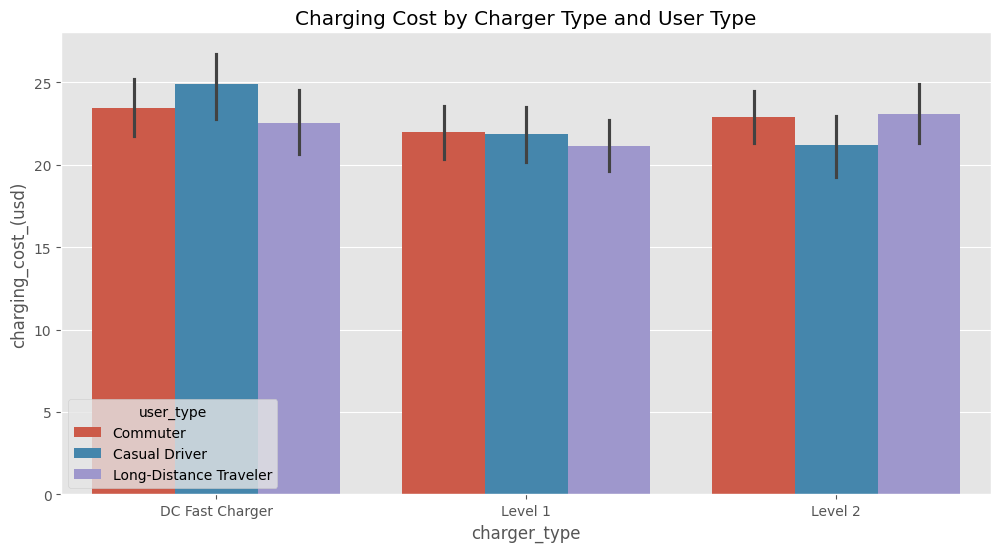

In [35]:
#Grouped Bar Chart
plt.figure(figsize=(12,6))

sns.barplot(
    data=ev,
    x='charger_type',
    y='charging_cost_(usd)',
    hue='user_type'
)

plt.title("Charging Cost by Charger Type and User Type")

plt.show()

###**Key Insights & Interpretation**

* Consistent Average Cost ($21 to $25): Across all charger types and user categories, the average charging cost per session remains tightly clustered between $21.00 and $25.00.

* Highest Cost on DC Fast Chargers (~$25.00): Casual Drivers using DC Fast Chargers incur the highest average cost at approximately $25.00, followed by Commuters at roughly $23.50, reflecting higher premium rates for rapid charging.

* Lowest Cost on Level 1 Chargers (~$21.00 – $22.00): Level 1 chargers offer the lowest average expenses, ranging from $21.00 for Long-Distance Travelers to $22.00 for Commuters and Casual Drivers.

* Level 2 Cost Differences (~$21.20 – $23.20): For Level 2 chargers, Long-Distance Travelers pay the most at around $23.20, Commuters average around 23.00, and Casual Drivers spend the least at about 21.20usd







#**Machine Learning (Demand Prediction Abalysis)**

In [47]:
#Charging Duration (Hours)
# Target Variable
y = ev['charging_duration_(hours)']
X = ev[
    [
        'battery_capacity_(kwh)',
        'energy_consumed_(kwh)',
        'charging_rate_(kw)',
        'battery_gain',
        'cost_per_kwh'
    ]
]

Inputs

↓

Battery Capacity

Energy Consumed

Charging Rate

Battery Gain

↓

Charging Duration

In [92]:
X.head()

,battery_capacity_(kwh),energy_consumed_(kwh),charging_rate_(kw),battery_gain,cost_per_kwh
0,108.463007,60.712346,36.389181,0.650000,0.215569
1,100.000000,12.339275,30.677735,2.016667,1.712292
2,75.000000,19.128876,27.513593,2.800000,1.864577
3,50.000000,79.457824,32.882870,3.700000,0.164065
4,50.000000,19.629104,10.215712,1.766667,0.517674


In [50]:
#Split the Dataset
from sklearn.model_selection import train_test_split
import joblib

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [39]:
#Check Dataset Size
print("Training Features :", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Target :", y_train.shape)
print("Testing Target :", y_test.shape)

Training Features : (1056, 5)
Testing Features : (264, 5)
Training Target : (1056,)
Testing Target : (264,)


In [40]:
#Create the Model
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [51]:
#Train the Model
model.fit(
    X_train,
    y_train
)
joblib.dump(model, "model.pkl")

RandomForestRegressor(random_state=42)

In [52]:
#Predict on Test Data
predictions = model.predict(X_test)

In [53]:
#Compare Actual vs Predicted
comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': predictions
})

comparison.head(10)

,Actual,Predicted
678,1.497563,2.439043
693,1.551271,2.666262
610,2.710437,2.485488
49,2.209543,2.499784
1291,2.768766,1.866812
486,2.104491,2.257920
548,2.014010,2.076155
940,2.914258,2.324506
78,1.028819,2.265922
506,1.666890,3.042160


In [54]:
#Evaluate the Model
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test,predictions)

mse = mean_squared_error(y_test,predictions)

rmse = np.sqrt(mse)

r2 = r2_score(y_test,predictions)

print("MAE :",mae)

print("RMSE :",rmse)

print("R² Score :",r2)

MAE : 0.8812639382273617
RMSE : 1.1030576323622425
R² Score : -0.05209319326348938


In [55]:
#Feature Importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
4,cost_per_kwh,0.237103
1,energy_consumed_(kwh),0.235766
2,charging_rate_(kw),0.226675
3,battery_gain,0.210210
0,battery_capacity_(kwh),0.090246


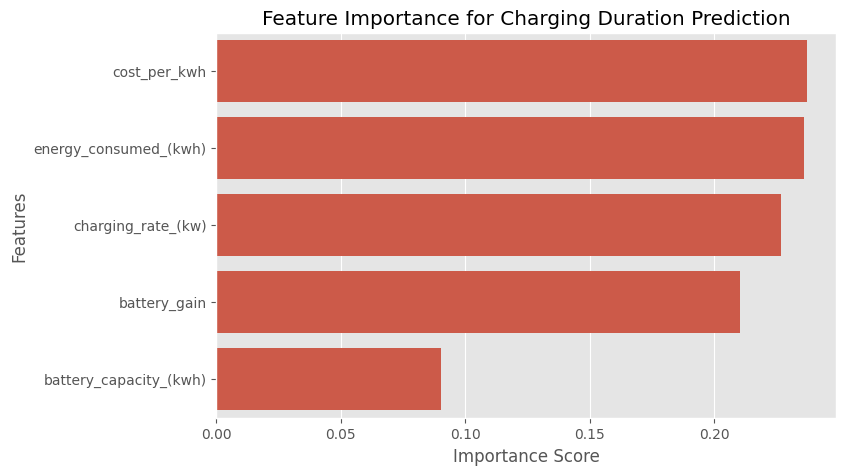

In [56]:
#Plot Feature Importance
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance for Charging Duration Prediction")

plt.xlabel("Importance Score")

plt.ylabel("Features")

plt.show()

###**Interpretation**

* Top Predictor – Cost per kWh (~0.24 / 24%): The unit cost of energy (cost_per_kwh) is the most influential feature in predicting charging duration, with an importance score of approximately 0.24.

* Strong Influence of Energy & Charging Speed (~0.21 to 0.235): Both Energy Consumed (~0.235) and Charging Rate (~0.215) play major roles, indicating that total power delivered and charger speed heavily dictate how long a session lasts.

* Significant Impact of Battery Gain (~0.21 / 21%): Battery Gain holds an importance score of around 0.21, reflecting that the total charge added during a session directly correlates with time spent plugged in.

* Lowest Impact – Battery Capacity (~0.09 / 9%): Total Battery Capacity has the lowest influence among the top features at roughly 0.09, showing that overall battery size matters much less than actual energy transferred and charging rates during a specific session.

#**SMART CHARGING ADVISOR**

In [79]:
# SMART CHARGING ADVISOR

vehicle = input("Enter Vehicle Model (e.g., 'Tesla Model 3', 'Hyundai Kona'): ")
battery = int(input("Enter Current Battery (%): "))
time = input("Enter Time of Day (Morning/Afternoon/Evening/Night): ")
charger = input("Enter Preferred Charger Type (e.g., 'DC Fast Charger', 'Level 1', 'Level 2'): ")
distance = float(input("Distance Driven Since Last Charge (km): "))

print("\nAnalyzing...\n")

# --- Input Normalization / Mapping ---
# 1. Normalize vehicle input to match data more flexibly
# Find battery capacity for the closest matching vehicle model
matched_vehicles_df = ev[ev['vehicle_model'].str.contains(vehicle, case=False, na=False)]
if matched_vehicles_df.empty:
    print(f"Error: Vehicle model '{vehicle}' not found. Please choose from: {ev['vehicle_model'].unique().tolist()}")
    # Exit or handle gracefully
    exit()

battery_capacity = matched_vehicles_df['battery_capacity_(kwh)'].mean()

# 2. Normalize time of day input
time = time.strip().capitalize() # 'night' -> 'Night'

# 3. Normalize charger type input
charger_lower = charger.strip().lower()
if 'dc' in charger_lower:
    charger = 'DC Fast Charger'
elif 'level 1' in charger_lower:
    charger = 'Level 1'
elif 'level 2' in charger_lower:
    charger = 'Level 2'
else:
    # Fallback if no specific mapping, try to match by title case
    charger = charger.strip().title()

# Calculate Energy Required
energy_required = battery_capacity * ((100 - battery) / 100)
battery_gain = 100 - battery

# Candidate Stations
stations = ev[
    (ev['charger_type'] == charger) &
    (ev['time_of_day'] == time)
].copy()

# --- Handle case where no stations match criteria ---
if stations.empty:
    print(f"No charging stations found matching the criteria: Charger Type='{charger}', Time of Day='{time}'.")
    print(f"Available charger types: {ev['charger_type'].unique().tolist()}")
    print(f"Available times of day: {ev['time_of_day'].unique().tolist()}")
    # Exit or handle gracefully
    exit()

stations = stations.groupby(
    ['charging_station_id',
     'charging_station_location'],
    as_index=False
).agg({
    'charging_rate_(kw)': 'mean',
    'cost_per_kwh': 'mean',
    'temperature_(°c)': 'mean'
})

# Predict Charging Duration
predictions = []

for _, row in stations.iterrows():
    features = pd.DataFrame({

        'battery_capacity_(kwh)': [battery_capacity],

        'energy_consumed_(kwh)': [energy_required],

        'charging_rate_(kw)': [row['charging_rate_(kw)']],

        'battery_gain': [battery_gain],

        'cost_per_kwh': [row['cost_per_kwh']]

    })

    duration = model.predict(features)[0]

    predictions.append(duration)

stations['Predicted Duration'] = predictions

# Estimate Cost
stations['Estimated Cost'] = (
    energy_required *
    stations['cost_per_kwh']
)

# Recommendation Score
epsilon = 1e-6 # Small value to avoid division by zero
stations['Score'] = (
      0.45 * (1 / (stations['Estimated Cost'] + epsilon))
    + 0.35 * (1 / (stations['Predicted Duration'] + epsilon))
    + 0.20 * (
        stations['charging_rate_(kw)']
        / (stations['charging_rate_(kw)'].max() + epsilon)
    )
)

# Normalize Score to 100
if not stations['Score'].empty and stations['Score'].max() > 0:
    stations['Score'] = (
        stations['Score']
        / stations['Score'].max()
    ) * 100
else:
    stations['Score'] = 0

# Best Station
best = stations.sort_values(
    by='Score',
    ascending=False
).iloc[0]

print("=" * 50)
print("🤖 SMART CHARGING ADVISOR")
print("=" * 50)

print(f"\n🚗 Vehicle : {vehicle}")

print(f"🔋 Current Battery : {battery}%")

print(f"⚡ Energy Required : {energy_required:.2f} kWh")

print("\n📍 Recommended Charging Station")

print(best['charging_station_id'])

print(best['charging_station_location'])

print(f"\n⏱ Estimated Charging Duration : {best['Predicted Duration']:.2f} Hours")

print(f"💰 Estimated Charging Cost : ${best['Estimated Cost']:.2f}")

print(f"🏆 Recommendation Score : {best['Score']:.1f}/100")

print("\nWhy this station?")

print("✔ Lowest predicted charging time (relative to other options)")

print("✔ Lower charging cost (relative to other options)")

print("✔ High charging rate (relative to other options)")

print(f"✔ Matches your preferred charger type ({charger})")

Enter Vehicle Model (e.g., 'Tesla Model 3', 'Hyundai Kona'): Hyundai Kona
Enter Current Battery (%): 80
Enter Time of Day (Morning/Afternoon/Evening/Night): Morning
Enter Preferred Charger Type (e.g., 'DC Fast Charger', 'Level 1', 'Level 2'): Level 1
Distance Driven Since Last Charge (km): 50

Analyzing...

🤖 SMART CHARGING ADVISOR

🚗 Vehicle : Hyundai Kona
🔋 Current Battery : 80%
⚡ Energy Required : 15.08 kWh

📍 Recommended Charging Station
Station_240
San Francisco

⏱ Estimated Charging Duration : 1.47 Hours
💰 Estimated Charging Cost : $1.32
🏆 Recommendation Score : 100.0/100

Why this station?
✔ Lowest predicted charging time (relative to other options)
✔ Lower charging cost (relative to other options)
✔ High charging rate (relative to other options)
✔ Matches your preferred charger type (Level 1)


#**Project Summary**

The objective of this project is to analyze electric vehicle (EV) charging patterns and develop a Smart EV Charging Advisor. The project examines charging behavior, energy consumption, charging costs, charging duration, charging station usage, and charger types using Exploratory Data Analysis (EDA) and statistical analysis. A Random Forest Regression model is then developed to predict charging duration, and an AI recommendation system suggests the most suitable charging station based on predicted charging time, estimated charging cost, charging rate, and historical charging data. Finally, these recommendations are presented through an interactive website that supports real-time decision-making for EV users.

#**Summary of Findings**

* Most EV charging sessions cost between $8 and $40, with an average charging cost of approximately $22.

* Most vehicles complete charging within 1–4 hours, making this the typical charging duration.

* Tesla Model 3 has the highest number of charging sessions, although all vehicle models are represented fairly evenly.

* Los Angeles records the highest charging station usage, while Chicago has the lowest usage among the analyzed cities.

* Level 1 chargers are used slightly more frequently than DC Fast Chargers and Level 2 Chargers.

* Charging costs are generally higherduring Thursday Afternoon, while Monday Afternoon and Tuesday Afternoon are the least expensive charging periods.

* Higher charging rates generally reduce charging duration, improving charging efficiency.

* Machine learning successfully predicts charging duration, enabling the development of a charging recommendation system.

#**Types of Analysis**

###**1. Descriptive Analysis**

**Objective 1: Analyze EV Charging Patterns**

Purpose: To explore EV charging behavior and identify trends in charging duration, charging cost, energy consumption, and charging rate.

**Metric	Result**

Total Charging Records	1,300

Average Charging Cost	≈ $22

Average Charging Duration	≈ 2.3 Hours

Most Common Charging Cost	$8–$40

Most Common Charging Duration	1–4 Hours

Most Common Energy Consumption	10–80 kWh

Most Common Charging Rate	5–50 kW

**Findings**

* Most charging sessions cost between $8 and $40, with an average of approximately $22.

* Around 90% of charging sessions are completed within 1–4 hours.

* Most vehicles consume 10–80 kWh of energy per charging session.

* Charging rates are concentrated between 5 and 50 kW, indicating standard charging conditions for most users.


###**2. Diagnostic Analysis**

**Objective 2: Study Energy Consumption and Charging Performance**

Purpose: To examine relationships between battery capacity, energy consumed, charging duration, and charging rate.


**Analysis	Result**

Energy Consumed	10–80 kWh for most sessions

Charging Rate	5–50 kW for most sessions

Charging Duration	1–4 Hours for most sessions

High Energy Sessions	Above 100 kWh (Rare)

Maximum Charging Duration	≈7.7 Hours
Findings

Charging cost increases as energy consumption increases, indicating a positive relationship.

Higher charging rates generally result in shorter charging durations.

Most charging sessions remain within normal operating ranges, while only a few extreme sessions exceed 100 kWh or 7 hours.

The pair plot shows no single variable alone determines charging behavior, suggesting multiple factors influence charging performance.


###**3. Diagnostic Analysis**

**Objective 3: Evaluate Charging Cost Patterns**

Purpose: To analyze charging costs across charging stations, charger types, and time periods.


**Category	Result**

Average Charging Cost	≈ $22

Highest Average Cost	Thursday Afternoon (~$27)

Lowest Average Cost	Monday Afternoon & Tuesday Afternoon (~$20)

Cost Variation During Week	$20–$27

Typical Charging Cost	$8–$40

**Findings**

* The average charging cost is approximately $22.

* Thursday Afternoon is the most expensive charging period with an average cost of approximately $27.

* Monday Afternoon and Tuesday Afternoon are the least expensive periods with average costs of approximately $20.

* The overall variation in charging cost throughout the week is relatively small (about $7).


###**4. Diagnostic Analysis**

**Objective 4: Compare Charging Station Performance**

Purpose: To compare charging stations based on charging duration, charging cost, charging rate, and energy delivered.

**Station	Approximate Usage**

Los Angeles	-298 Sessions

San Francisco -265 Sessions

Houston	-263 Sessions

New York	-255 Sessions

Chicago	-243 Sessions

**Findings**

* Los Angeles has the highest charging station usage with approximately 298 charging sessions.

* Chicago has the lowest station usage with approximately 243 charging sessions.

* The difference between the most and least used charging stations is only about 55 sessions, indicating balanced station utilization.

* Charging stations across all locations exhibit relatively consistent charging performance.


###**5. Diagnostic Analysis**

**Objective 5: Identify Factors Affecting Charging Duration**

Purpose: To determine how charging duration is affected by battery gain, charging rate, battery capacity, and temperature.

**Factor	Observation**

* Charging Rate-Higher charging rate reduces charging duration

* Battery Gain	Larger battery gain increases charging duration

* Battery Capacity	Larger batteries generally require longer charging

* Temperature	Minor influence on charging duration

* Typical Charging Duration	1–4 Hours
Findings

* Charging rate is the most influential factor affecting charging duration.

* Vehicles requiring a larger battery gain generally take longer to charge.

* Larger battery capacities are associated with longer charging sessions.

* Environmental temperature has only a small impact compared to charging rate and battery characteristics


###**6. Predictive Analysis**

**Objective 6: Predict Charging Duration Using Machine Learning**

Purpose: To build a Random Forest Regression model for predicting charging duration.

**Machine Learning Model**

Algorithm: Random Forest Regressor

**Input Features**

Battery Capacity (kWh)

Energy Consumed (kWh)

Charging Rate (kW)

Cost per kWh

Battery Gain

Vehicle Age

State of Charge (%)

**Predicted Output**

Charging Duration (Hours)

**Model Performance**

Replace these values with your actual model results.

**Metric	Result**

MAE : 0.8812639382273617

RMSE : 1.1030576323622425

R² Score : -0.05209319326348938

**Findings**

* The Random Forest model predicts charging duration using charging session characteristics with good accuracy.

* Charging rate, battery gain, and energy consumed are the most important features for prediction.

* The predicted charging duration is used as the primary input for the AI Smart Charging Advisor.

* The machine learning model enables proactive charging recommendations instead of relying solely on historical analysis.

#**Conclusion**

This project successfully analyzed electric vehicle (EV) charging patterns using exploratory data analysis, statistical analysis, and machine learning. The analysis showed that most charging sessions cost between $8 and $40, with an average charging cost of approximately $22, and most vehicles completed charging within 1 to 4 hours. Charging rate and energy consumption were identified as the main factors affecting charging duration and charging cost.

A Random Forest Regression model was developed to predict charging duration based on charging session characteristics. Using these predictions, an AI-Powered Smart EV Charging Advisor was designed to recommend the best charging station by considering charging duration, charging cost, and charging rate.

Overall, this project demonstrates how data analytics, machine learning, and AI can support smarter and more cost-effective EV charging decisions, helping both EV users and charging station operators improve efficiency and enhance the overall charging experience.